# Clustering Analysis — Customer Segmentation

## Step 1: Import necessary libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

## 1) Data Loading and Exploration (10pts)

In [14]:
# Use Pandas to load the dataset
df = pd.read_csv('Wholesale customers data.csv')

# Display the first 5 rows of the dataset
print("=== First 5 rows ===")
df.head()

=== First 5 rows ===


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [15]:
# Explore the dataset
print("\n=== Dataset Info ===")
print(df.info())

print("\n=== Dataset Description (describe) ===")
df.describe()


=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None

=== Dataset Description (describe) ===


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [16]:
# Check for missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

=== Missing Values ===
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Total missing values: 0


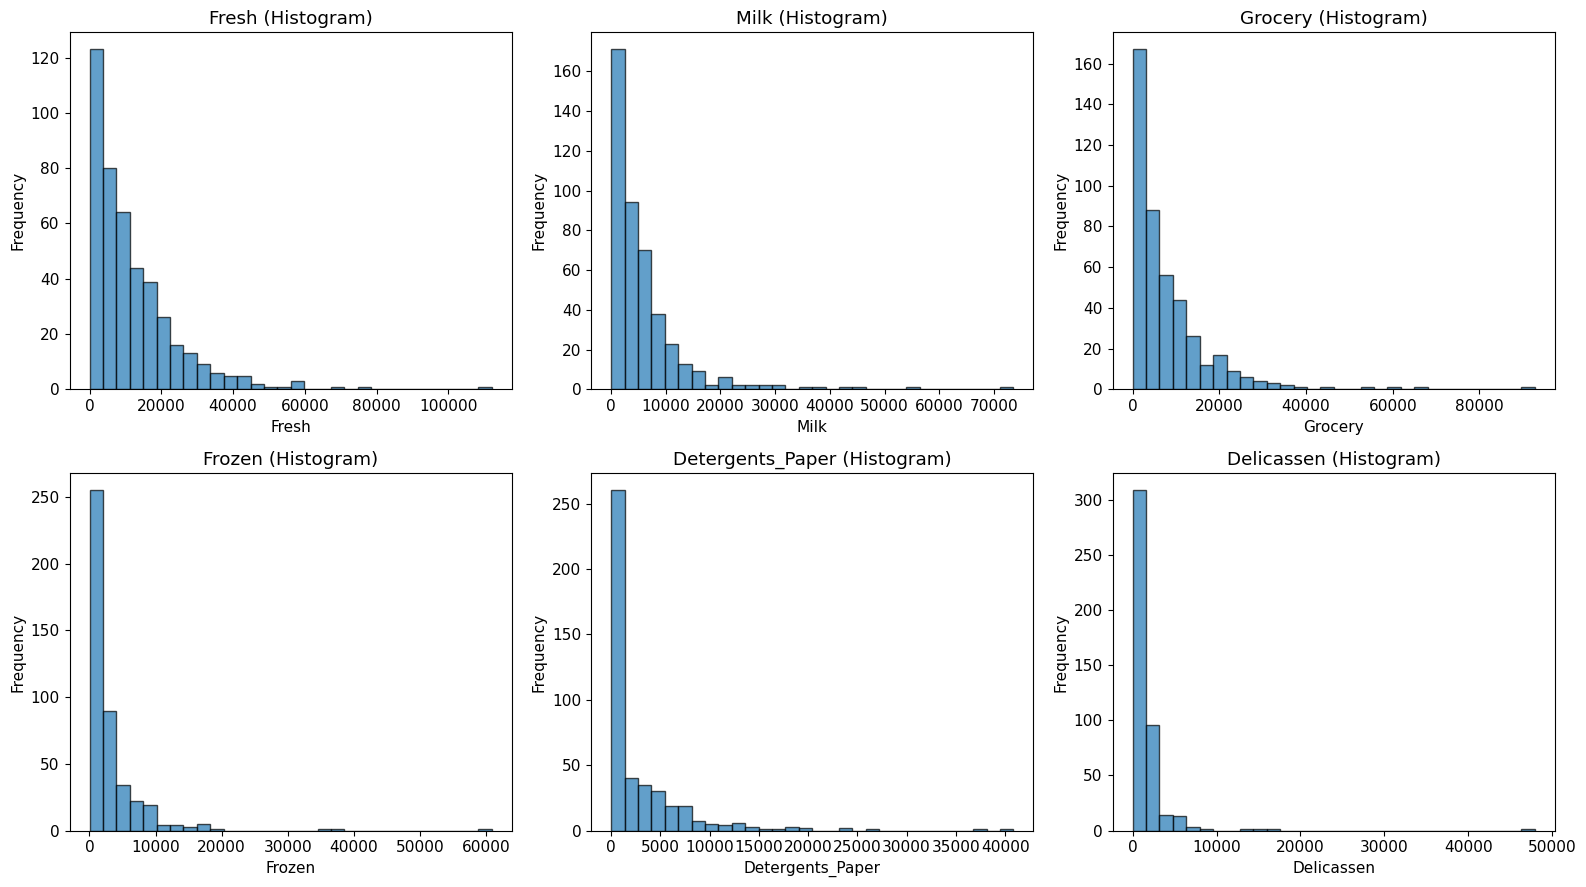

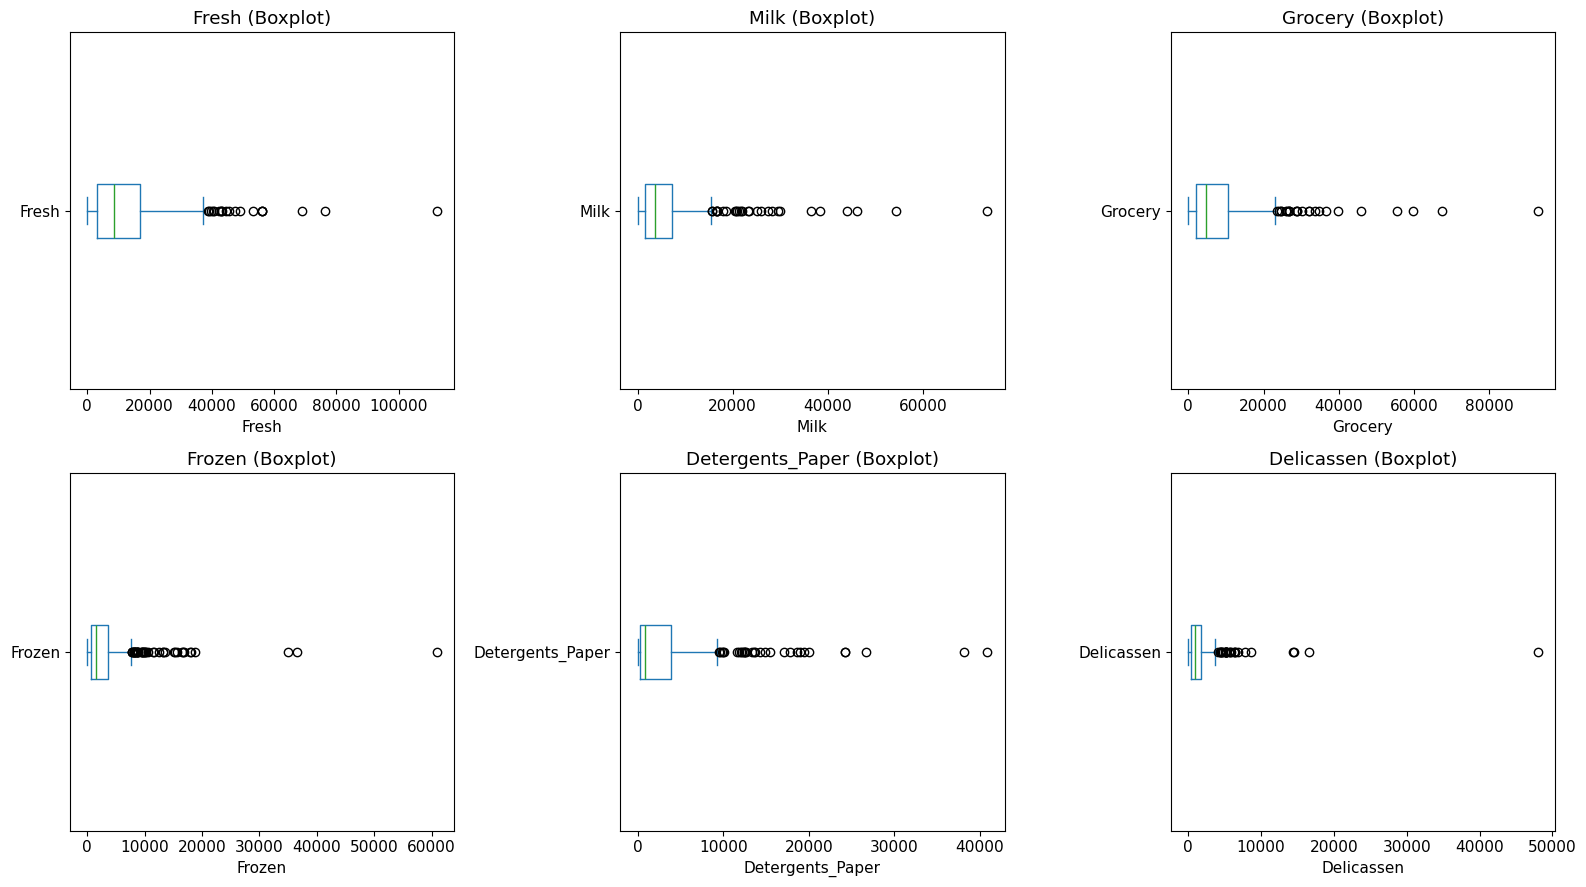

In [17]:
# Visualize distributions of key features using histograms and boxplots
feature_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# Histograms
fig1, axes1 = plt.subplots(2, 3, figsize=(16, 9))
for i, feat in enumerate(feature_cols):
    df[feat].plot.hist(ax=axes1.flat[i], bins=30, edgecolor='black', alpha=0.7)
    axes1.flat[i].set_title(f'{feat} (Histogram)')
    axes1.flat[i].set_xlabel(feat)
    axes1.flat[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxplots
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9))
for i, feat in enumerate(feature_cols):
    df[feat].plot.box(ax=axes2.flat[i], vert=False)
    axes2.flat[i].set_title(f'{feat} (Boxplot)')
    axes2.flat[i].set_xlabel(feat)
plt.tight_layout()
plt.show()

## 2) Data Preprocessing (15pts)

In [18]:
# Check the dataset columns and confirm which columns will be used for clustering
print(f"All columns: {list(df.columns)}")

# Channel and Region are categorical; we use the 6 spending features for clustering.
# Category: Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen
feature_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X = df[feature_cols].copy()

print(f"\nSelected features: {feature_cols}")
print(f"Feature matrix shape: {X.shape}")

All columns: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Selected features: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Feature matrix shape: (440, 6)


In [19]:
# Standardize the features to zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling (≈0):", np.round(X_scaled.mean(axis=0), 6))
print("Std  after scaling (≈1):", np.round(X_scaled.std(axis=0), 6))
print(f"Scaled feature matrix shape: {X_scaled.shape}")

Mean after scaling (≈0): [-0.  0. -0.  0.  0. -0.]
Std  after scaling (≈1): [1. 1. 1. 1. 1. 1.]
Scaled feature matrix shape: (440, 6)


## 3) Model Building (30pts)

### 3.1) K-means Clustering

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10, max_iter=300)#用10 组不同随机初始中心点分别运行 KMeans   单次 KMeans 迭代的最大循环次数，达到 300 次或提前收敛（中心点不再变化）就停止。
start = time.time()
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_time = time.time() - start

print(f"K-means (k=5):")
print(f"  Fit time: {kmeans_time:.4f} s")
print(f"  Clusters: {len(np.unique(kmeans_labels))}")
print(f"  Cluster sizes: {np.bincount(kmeans_labels)}")
print(f"  Labels: {kmeans_labels}")

K-means (k=5):
  Fit time: 4.5290 s
  Clusters: 5
  Cluster sizes: [270  10  63  96   1]
  Labels: [0 3 3 0 2 0 0 0 0 3 3 0 2 3 3 0 3 0 0 0 0 0 2 3 3 0 0 0 3 2 0 0 0 2 0 3 2
 3 3 2 2 0 3 3 3 3 3 1 3 3 0 0 2 3 0 0 1 3 0 0 0 1 0 3 0 1 0 3 0 0 2 2 0 2
 0 0 0 3 0 0 0 3 3 0 0 1 1 2 0 2 0 0 1 2 3 0 0 0 0 0 3 3 0 2 0 0 3 3 0 3 0
 3 2 0 0 0 0 0 0 0 0 0 0 0 2 2 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 3 0 0
 0 2 0 0 0 0 0 3 3 0 0 3 3 0 0 3 0 3 3 0 0 0 3 3 0 3 0 3 2 0 0 0 0 2 3 4 0
 0 0 0 3 3 0 0 0 3 0 2 2 3 0 0 3 3 2 0 0 3 0 0 0 3 0 1 0 0 3 3 3 0 3 0 0 3
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 0 3 3 0 0 0 0 0 1 0 2 3 2 0 0 2
 2 0 0 0 0 3 3 3 0 3 0 0 0 0 2 0 0 2 2 0 0 0 0 2 2 2 2 0 0 0 2 0 0 0 3 0 0
 0 0 0 0 0 3 3 3 3 3 3 0 0 3 0 2 3 0 0 3 0 0 0 3 0 0 0 0 0 2 0 0 0 0 0 3 0
 1 2 2 0 0 0 0 3 3 0 3 0 0 3 2 0 3 0 3 0 3 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0
 2 2 0 0 0 0 3 2 0 0 2 2 2 0 3 0 0 0 0 0 0 0 0 2 0 0 3 0 0 0 0 2 0 0 0 0 2
 3 0 0 0 0 0 2 0 0 3 0 3 0 3 0 0 0 0 2 3 2 0 0 0 2 0 0 0 2 2 3 0 0]


### 3.2) Hierarchical Clustering

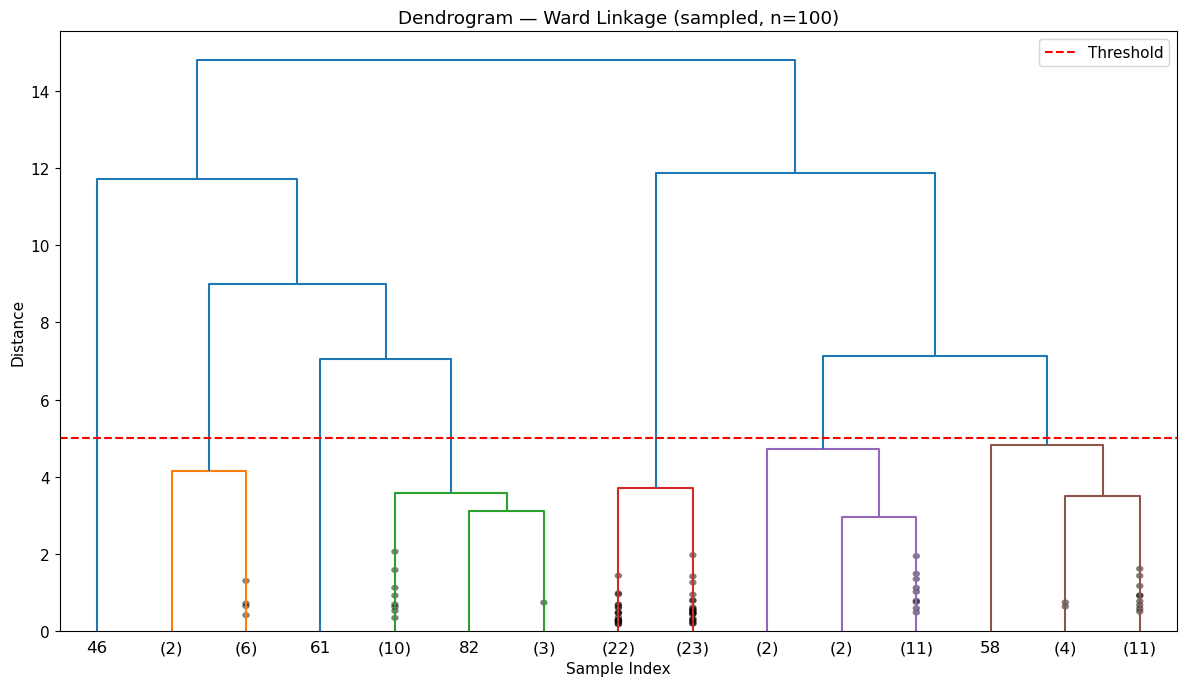

In [21]:
# Plot dendrogram using Ward's linkage (use a sample for clearer visualization)
sample_size = min(100, X_scaled.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(Z, truncate_mode='lastp', p=15, show_contracted=True, color_threshold=5)
plt.axhline(y=5, color='r', linestyle='--', label='Threshold')
plt.title('Dendrogram — Ward Linkage (sampled, n=100)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
start = time.time()
agg_labels = agg.fit_predict(X_scaled)
agg_time = time.time() - start

print(f"Agglomerative (n_clusters=5, linkage='ward'):")
print(f"  Fit time: {agg_time:.4f} s")
print(f"  Clusters: {len(np.unique(agg_labels))}")
print(f"  Cluster sizes: {np.bincount(agg_labels)}")

Agglomerative (n_clusters=5, linkage='ward'):
  Fit time: 0.0050 s
  Clusters: 5
  Cluster sizes: [153   5 104   1 177]


### 3.3) DBSCAN Clustering

In [23]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
start = time.time()
dbscan_labels = dbscan.fit_predict(X_scaled)
dbscan_time = time.time() - start

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)

print(f"DBSCAN (eps=0.5, min_samples=5):")
print(f"  Fit time: {dbscan_time:.4f} s")
print(f"  Clusters: {n_clusters_dbscan}")
print(f"  Noise points: {n_noise}")
print(f"  Unique labels: {np.unique(dbscan_labels)}")
if n_clusters_dbscan > 0:
    print(f"  Cluster sizes: {np.bincount(dbscan_labels[dbscan_labels >= 0])}")
print(f"  Labels: {dbscan_labels}")

DBSCAN (eps=0.5, min_samples=5):
  Fit time: 0.0060 s
  Clusters: 2
  Noise points: 174
  Unique labels: [-1  0  1]
  Cluster sizes: [261   5]
  Labels: [ 0  0 -1  0 -1  0  0  0  0 -1 -1  0 -1 -1 -1  0  0 -1  0  0  0  0 -1 -1
 -1  0  0  0 -1  1 -1  0  0 -1  0  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  0 -1  0  0 -1  0  0  0 -1 -1  0  0  0 -1 -1 -1  0 -1 -1 -1 -1  0 -1 -1
 -1 -1  0  0 -1 -1  0  0  0  0  0  0  0 -1 -1 -1  0 -1  0  0 -1 -1  0  0
 -1  0  0  0 -1 -1  0 -1  0  0  0 -1  0 -1  0 -1 -1  0  0  0  0  0  0  0
  0  0  0 -1 -1 -1  0 -1  0  1  0  0  0  0  0  0 -1 -1 -1  0  0 -1 -1  0
  0 -1  0  0  0  0  0  0  0 -1  0 -1 -1  0  0  0  0  0  0 -1 -1 -1 -1  0
  0  0  0 -1  0 -1  0  0 -1 -1  0 -1  0 -1  0 -1  0  0  0 -1 -1  0 -1  0
  0 -1  0  0 -1  0  0  0 -1 -1 -1  0  0 -1  0 -1  0 -1  0 -1  0  0  0 -1
 -1  0 -1  0  0  0  0  0  0  0  0  0 -1  0 -1 -1  0  0  0  0  0  0  0 -1
 -1  0  0  0  0 -1  0  0  0  0  0 -1  0 -1 -1  0  0 -1 -1 -1  0  0  0 -1
  0 -1 -1 -1 -1  0  0  0 -1 -1  0  0 -1 -1  

## 4) Model Evaluation (15pts)

In [24]:
# Define a function to compute Silhouette Score
# — requires at least two non-noise clusters
def compute_silhouette(X, labels):
    unique_labels = set(labels) - {-1}
    if len(unique_labels) < 2:
        return np.nan
    return silhouette_score(X, labels)

# Compute metrics for all three methods
sil_kmeans = compute_silhouette(X_scaled, kmeans_labels)
sil_agg    = compute_silhouette(X_scaled, agg_labels)
sil_dbscan = compute_silhouette(X_scaled, dbscan_labels)

print(f"Silhouette Score — K-means:     {sil_kmeans:.4f}")
print(f"Silhouette Score — Agglomerative:{sil_agg:.4f}")
print(f"Silhouette Score — DBSCAN:      {sil_dbscan:.4f}" if not np.isnan(sil_dbscan) else "Silhouette Score — DBSCAN: N/A (fewer than 2 non-noise clusters)")

Silhouette Score — K-means:     0.3690
Silhouette Score — Agglomerative:0.2399
Silhouette Score — DBSCAN:      0.1958


In [25]:
# Tabulate results
eval_df = pd.DataFrame({
    'Algorithm': ['K-means (k=5)', 'Agglomerative (k=5, ward)', 'DBSCAN (eps=0.5, min_samples=5)'],
    'Silhouette Score': [sil_kmeans, sil_agg, sil_dbscan],
    'Fit time (s)': [kmeans_time, agg_time, dbscan_time],
    'Number of Clusters': [len(np.unique(kmeans_labels)),
                           len(np.unique(agg_labels)),
                           n_clusters_dbscan]
})
print("\n=== Evaluation Summary ===")
eval_df


=== Evaluation Summary ===


,Algorithm,Silhouette Score,Fit time (s),Number of Clusters
0,K-means (k=5),0.369040,4.529032,5
1,"Agglomerative (k=5, ward)",0.239884,0.004992,5
2,"DBSCAN (eps=0.5, min_samples=5)",0.195811,0.006005,2


## 5) Hyperparameter Tuning (25pts)

In [26]:
# PCA for dimensionality reduction (useful for 2D cluster visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA variance explained: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {sum(pca.explained_variance_ratio_):.2%}")

PCA variance explained: [0.44082893 0.283764  ]
Total variance captured: 72.46%


### 5.1) K-means Clustering: tuning k

In [27]:
k_range = range(2, 11)
kmeans_sil = []
kmeans_inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels)
    kmeans_sil.append(s)
    kmeans_inertias.append(km.inertia_)
    print(f"  k={k}: Silhouette={s:.4f}, Inertia={km.inertia_:.2f}")

best_k = list(k_range)[np.argmax(kmeans_sil)]
best_kmeans_sil = max(kmeans_sil)
print(f"\n>>> Best K-means: k={best_k}, Silhouette={best_kmeans_sil:.4f}")

  k=2: Silhouette=0.5472, Inertia=1956.12
  k=3: Silhouette=0.5483, Inertia=1608.43
  k=4: Silhouette=0.3485, Inertia=1317.84
  k=5: Silhouette=0.3690, Inertia=1058.77
  k=6: Silhouette=0.3782, Inertia=915.74
  k=7: Silhouette=0.3343, Inertia=825.40
  k=8: Silhouette=0.3201, Inertia=737.39
  k=9: Silhouette=0.3090, Inertia=661.45
  k=10: Silhouette=0.3112, Inertia=605.92

>>> Best K-means: k=3, Silhouette=0.5483


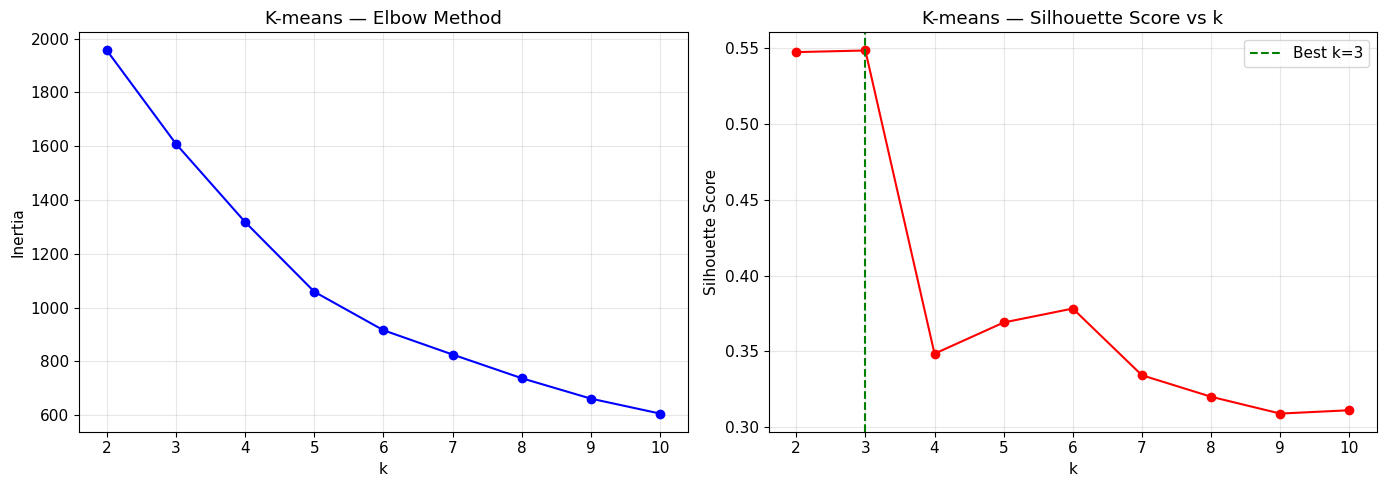

In [28]:
# Plot: Elbow and Silhouette vs k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
k_list = list(k_range)

axes[0].plot(k_list, kmeans_inertias, 'bo-', marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('K-means — Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_list, kmeans_sil, 'ro-', marker='o')
axes[1].axvline(x=best_k, color='g', linestyle='--', label=f'Best k={best_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-means — Silhouette Score vs k')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

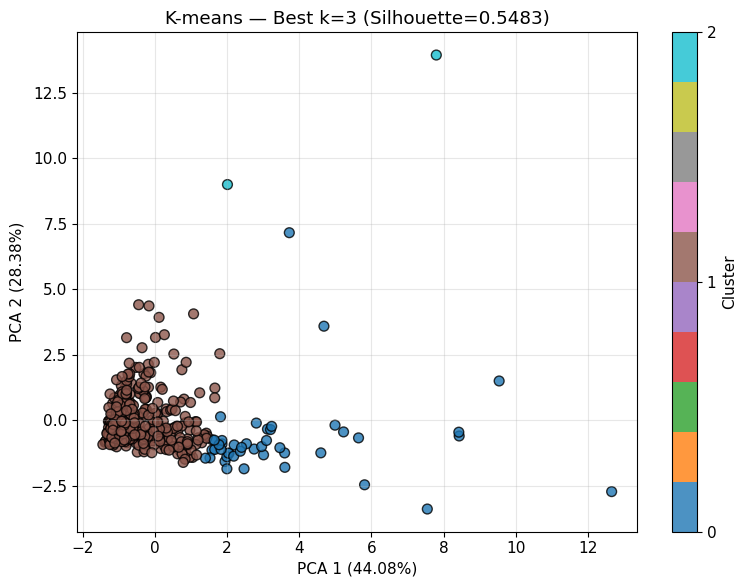

In [29]:
# Plot clusters under optimal k
best_km = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
best_km_labels = best_km.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_km_labels, cmap='tab10', s=50, edgecolor='black', alpha=0.8)
plt.colorbar(sc, ticks=range(best_k), label='Cluster')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'K-means — Best k={best_k} (Silhouette={best_kmeans_sil:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2) Hierarchical Clustering: tuning linkage and k


>>> Best Agglomerative: linkage=complete, k=2, Silhouette=0.8638


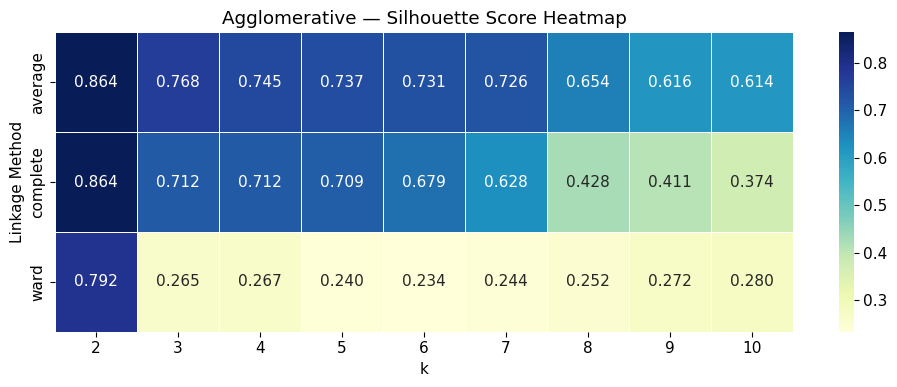

In [30]:
linkage_options = ['ward', 'complete', 'average']
agg_k_range = range(2, 11)
agg_results = []

for lnk in linkage_options:
    for k in agg_k_range:
        try:
            ac = AgglomerativeClustering(n_clusters=k, linkage=lnk)
            labels = ac.fit_predict(X_scaled)
            s = silhouette_score(X_scaled, labels)
            agg_results.append({'linkage': lnk, 'k': k, 'silhouette': s})
        except Exception:
            continue

agg_df = pd.DataFrame(agg_results)
best_agg_idx = agg_df['silhouette'].idxmax()
best_agg_row = agg_df.loc[best_agg_idx]
print(f"\n>>> Best Agglomerative: linkage={best_agg_row['linkage']}, k={int(best_agg_row['k'])}, "
      f"Silhouette={best_agg_row['silhouette']:.4f}")

# Heatmap visualization
pivot = agg_df.pivot_table(index='linkage', columns='k', values='silhouette')
plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('Agglomerative — Silhouette Score Heatmap')
plt.xlabel('k'); plt.ylabel('Linkage Method')
plt.tight_layout()
plt.show()

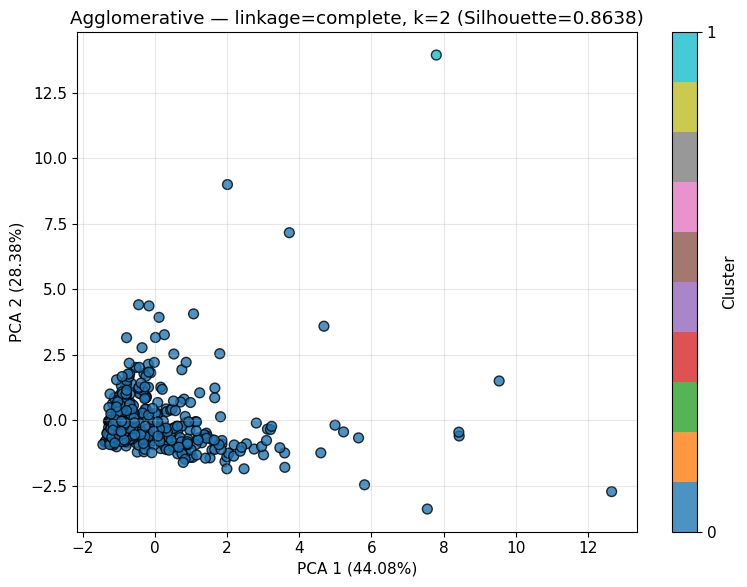

In [31]:
# Plot clusters under optimal parameters
best_agg_linkage = best_agg_row['linkage']
best_agg_k = int(best_agg_row['k'])
best_agg_sil = best_agg_row['silhouette']

best_agg = AgglomerativeClustering(n_clusters=best_agg_k, linkage=best_agg_linkage)
best_agg_labels = best_agg.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_agg_labels, cmap='tab10', s=50, edgecolor='black', alpha=0.8)
plt.colorbar(sc, ticks=range(best_agg_k), label='Cluster')
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'Agglomerative — linkage={best_agg_linkage}, k={best_agg_k} (Silhouette={best_agg_sil:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3) DBSCAN Clustering: tuning eps and min_samples

In [32]:
eps_range = [0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2]
min_samples_range = [3, 5, 7, 10, 15]
dbscan_results = []

for eps in eps_range:
    for ms in min_samples_range:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        unique = set(labels) - {-1}
        n_cl = len(unique)
        n_noise = np.sum(labels == -1)
        s = silhouette_score(X_scaled, labels) if n_cl >= 2 else np.nan
        dbscan_results.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_cl,
                               'n_noise': n_noise, 'silhouette': s})

dbscan_df = pd.DataFrame(dbscan_results)
display(dbscan_df)

# Find best configuration
valid = dbscan_df.dropna(subset=['silhouette'])
if len(valid) > 0:
    best_dbscan_idx = valid['silhouette'].idxmax()
    best_dbscan_row = valid.loc[best_dbscan_idx]
    print(f"\n>>> Best DBSCAN: eps={best_dbscan_row['eps']}, min_samples={int(best_dbscan_row['min_samples'])}, "
          f"n_clusters={int(best_dbscan_row['n_clusters'])}, n_noise={int(best_dbscan_row['n_noise'])}, "
          f"Silhouette={best_dbscan_row['silhouette']:.4f}")
else:
    best_dbscan_row = None
    print("\nNo valid DBSCAN configuration found (need >= 2 non-noise clusters).")

,eps,min_samples,n_clusters,n_noise,silhouette
0,0.2,3,12,371,-0.361433
1,0.2,5,2,411,-0.258742
2,0.2,7,2,420,-0.275576
3,0.2,10,0,440,NaN
4,0.2,15,0,440,NaN
5,0.3,3,6,299,-0.295744
6,0.3,5,2,321,-0.129079
7,0.3,7,2,333,-0.162637
8,0.3,10,1,363,NaN
9,0.3,15,1,383,NaN



>>> Best DBSCAN: eps=1.2, min_samples=3, n_clusters=2, n_noise=32, Silhouette=0.4195


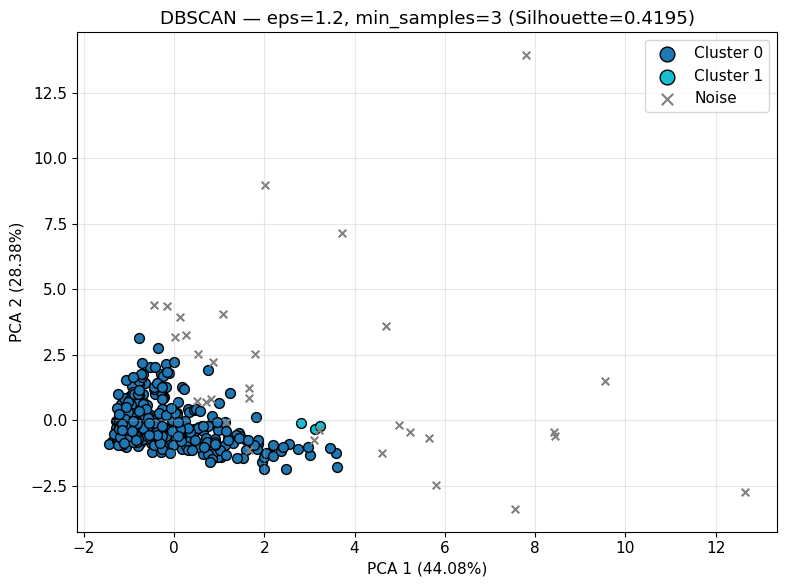

In [33]:
# Plot clusters under optimal DBSCAN parameters
if best_dbscan_row is not None:
    best_eps = best_dbscan_row['eps']
    best_ms = int(best_dbscan_row['min_samples'])
    best_dbscan_sil = best_dbscan_row['silhouette']

    best_db = DBSCAN(eps=best_eps, min_samples=best_ms)
    best_db_labels = best_db.fit_predict(X_scaled)
    unique_cl = set(best_db_labels) - {-1}
    n_noise = np.sum(best_db_labels == -1)

    plt.figure(figsize=(8, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_cl), 1)))
    for i, label in enumerate(sorted(unique_cl)):
        mask = best_db_labels == label
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[i]],
                    s=50, edgecolor='black', label=f'Cluster {label}')
    if n_noise > 0:
        plt.scatter(X_pca[best_db_labels == -1, 0], X_pca[best_db_labels == -1, 1],
                    c='gray', s=30, marker='x', label='Noise')
    plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.title(f'DBSCAN — eps={best_eps}, min_samples={best_ms} (Silhouette={best_dbscan_sil:.4f})')
    plt.legend(markerscale=1.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: no valid DBSCAN configuration found.")

## 6) Performance Comparison (5pts)

In [34]:
# Summarize best configuration for each algorithm in a table
best_kmeans_sil_val = best_kmeans_sil
best_agg_sil_val = best_agg_sil
best_dbscan_sil_val = best_dbscan_row['silhouette'] if best_dbscan_row is not None else np.nan

comparison = pd.DataFrame({
    'Algorithm': ['K-means', 'Agglomerative', 'DBSCAN'],
    'Best Parameter': [
        f'k={best_k}',
        f'linkage={best_agg_linkage}, k={best_agg_k}',
        f'eps={best_eps}, min_samples={best_ms}' if best_dbscan_row is not None else 'N/A'
    ],
    'Best Silhouette': [best_kmeans_sil_val, best_agg_sil_val, best_dbscan_sil_val]
})
print("=== Best Configuration Summary ===")
comparison

=== Best Configuration Summary ===


,Algorithm,Best Parameter,Best Silhouette
0,K-means,k=3,0.548287
1,Agglomerative,"linkage=complete, k=2",0.863801
2,DBSCAN,"eps=1.2, min_samples=3",0.419507


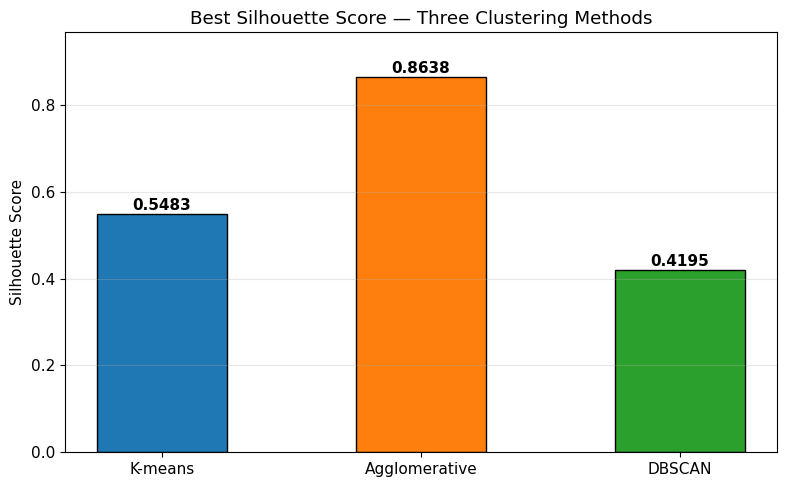


=== Conclusion ===
Best performing algorithm: Agglomerative (Silhouette = 0.8638)
A higher Silhouette Score indicates better-defined, more separated clusters.


In [35]:
# Plot bar chart of best Silhouette Scores for three methods
algorithms = ['K-means', 'Agglomerative', 'DBSCAN']
sil_values = [best_kmeans_sil_val, best_agg_sil_val, best_dbscan_sil_val]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(algorithms, sil_values, color=['#1f77b4', '#ff7f0e', '#2ca02c'],
              edgecolor='black', width=0.5)
for bar, val in zip(bars, sil_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Silhouette Score')
ax.set_title('Best Silhouette Score — Three Clustering Methods')
ax.set_ylim(0, max(sil_values) * 1.12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusion
best_idx = np.nanargmax(sil_values)
print(f"\n=== Conclusion ===")
print(f"Best performing algorithm: {algorithms[best_idx]} "
      f"(Silhouette = {sil_values[best_idx]:.4f})")
print("A higher Silhouette Score indicates better-defined, more separated clusters.")